In [120]:
import pandas as pd
import numpy as np 
import time 
import datetime 
import matplotlib.pyplot as plt 
%matplotlib inline  
import plotly.express as px
import plotly.graph_objects as go 
from sklearn.preprocessing import StandardScaler

In [121]:
orig_df = pd.read_csv(
    r"C:\Users\USER\Time_series\testset.csv",
    low_memory=False
)

In [122]:
print(orig_df.shape)
print(orig_df.columns)
orig_df.head()

(100990, 20)
Index(['datetime_utc', ' _conds', ' _dewptm', ' _fog', ' _hail',
       ' _heatindexm', ' _hum', ' _precipm', ' _pressurem', ' _rain', ' _snow',
       ' _tempm', ' _thunder', ' _tornado', ' _vism', ' _wdird', ' _wdire',
       ' _wgustm', ' _windchillm', ' _wspdm'],
      dtype='object')


,datetime_utc,_conds,_dewptm,_fog,_hail,_heatindexm,_hum,_precipm,_pressurem,_rain,_snow,_tempm,_thunder,_tornado,_vism,_wdird,_wdire,_wgustm,_windchillm,_wspdm
0,19961101-11:00,Smoke,9.0,0,0,NaN,27.0,NaN,1010.0,0,0,30.0,0,0,5.0,280.0,West,NaN,NaN,7.4
1,19961101-12:00,Smoke,10.0,0,0,NaN,32.0,NaN,-9999.0,0,0,28.0,0,0,NaN,0.0,North,NaN,NaN,NaN
2,19961101-13:00,Smoke,11.0,0,0,NaN,44.0,NaN,-9999.0,0,0,24.0,0,0,NaN,0.0,North,NaN,NaN,NaN
3,19961101-14:00,Smoke,10.0,0,0,NaN,41.0,NaN,1010.0,0,0,24.0,0,0,2.0,0.0,North,NaN,NaN,NaN
4,19961101-16:00,Smoke,11.0,0,0,NaN,47.0,NaN,1011.0,0,0,23.0,0,0,1.2,0.0,North,NaN,NaN,0.0


In [123]:
df = orig_df.copy()

df.columns = df.columns.str.strip()

df = df[['datetime_utc', '_tempm', '_pressurem', '_hum']]

df.columns = ['Date', 'Temperature', 'Pressure', 'Humidity']

print(df.head())

             Date  Temperature  Pressure  Humidity
0  19961101-11:00         30.0    1010.0      27.0
1  19961101-12:00         28.0   -9999.0      32.0
2  19961101-13:00         24.0   -9999.0      44.0
3  19961101-14:00         24.0    1010.0      41.0
4  19961101-16:00         23.0    1011.0      47.0


In [124]:
df.describe()

,Temperature,Pressure,Humidity
count,100317.000000,1.007580e+05,100233.000000
mean,25.451269,1.932331e+03,57.909481
std,8.482859,3.183786e+05,23.807771
min,1.000000,-9.999000e+03,4.000000
25%,19.000000,1.002000e+03,39.000000
50%,27.000000,1.008000e+03,59.000000
75%,32.000000,1.014000e+03,78.000000
max,90.000000,1.010614e+08,243.000000


In [125]:

display(df.quantile([0, 0.25, 0.5, 0.75, 1], numeric_only=True))

,Temperature,Pressure,Humidity
0.00,1.0,-9999.0,4.0
0.25,19.0,1002.0,39.0
0.50,27.0,1008.0,59.0
0.75,32.0,1014.0,78.0
1.00,90.0,101061443.0,243.0


In [126]:
df.shape

(100990, 4)

In [127]:
df = df[(df['Humidity'] >= 39) & (df['Humidity'] <= 78)]
df = df[(df['Pressure'] >= 1002.0) & (df['Pressure'] <= 1014.0)]
df = df[(df['Temperature'] >= 19.0) & (df['Temperature'] <= 32.0)]

In [128]:

df.shape
     

(19874, 4)

In [129]:

max_temp = np.max(df['Temperature'])
max_pres = np.max(df['Pressure'])
max_humid = np.max(df['Humidity'])

min_temp = np.min(df['Temperature'])
min_pres = np.min(df['Pressure'])
min_humid = np.min(df['Humidity'])

print(f'Max Temp : {max_temp}')
print(f'Max Pressure : {max_pres}')
print(f'Max Humidity : {max_humid}')

print(f'Min Temp : {min_temp}')
print(f'Min Pressure : {min_pres}')
print(f'Min Humidity : {min_humid}')

Max Temp : 32.0
Max Pressure : 1014.0
Max Humidity : 78.0
Min Temp : 19.0
Min Pressure : 1002.0
Min Humidity : 39.0


In [130]:

df.isnull().sum()

Date           0
Temperature    0
Pressure       0
Humidity       0
dtype: int64

In [131]:

print('Dataframe shape : {}'.format(df.shape))

Dataframe shape : (19874, 4)


In [132]:
idx = pd.date_range('1996-11-01 14:00:00', periods=19874 , freq='1h')

In [133]:
print(df.head())
print(df.columns)
print(df.index)

             Date  Temperature  Pressure  Humidity
3  19961101-14:00         24.0    1010.0      41.0
4  19961101-16:00         23.0    1011.0      47.0
5  19961101-17:00         21.0    1011.0      56.0
6  19961101-18:00         21.0    1010.0      60.0
9  19961101-21:00         19.0    1010.0      68.0
Index(['Date', 'Temperature', 'Pressure', 'Humidity'], dtype='object')
Index([     3,      4,      5,      6,      9,     10,     11,     12,     13,
           14,
       ...
       100931, 100932, 100933, 100958, 100966, 100973, 100974, 100975, 100981,
       100983],
      dtype='int64', length=19874)


In [134]:

df.head()

,Date,Temperature,Pressure,Humidity
3,19961101-14:00,24.0,1010.0,41.0
4,19961101-16:00,23.0,1011.0,47.0
5,19961101-17:00,21.0,1011.0,56.0
6,19961101-18:00,21.0,1010.0,60.0
9,19961101-21:00,19.0,1010.0,68.0


In [135]:
df_array = np.array(df) 
df_array
     

array([['19961101-14:00', 24.0, 1010.0, 41.0],
       ['19961101-16:00', 23.0, 1011.0, 47.0],
       ['19961101-17:00', 21.0, 1011.0, 56.0],
       ...,
       ['20170423-00:00', 27.0, 1002.0, 45.0],
       ['20170423-18:00', 30.0, 1002.0, 41.0],
       ['20170424-00:00', 26.0, 1004.0, 40.0]], dtype=object)

In [136]:
df_array = df_array[:5000]
df_array.shape 
     

(5000, 4)

In [137]:
from sklearn.preprocessing import StandardScaler

numeric_df = df.select_dtypes(include=["number"])

scaler = StandardScaler()
scaled_df = pd.DataFrame(
    scaler.fit_transform(numeric_df),
    columns=numeric_df.columns,
    index=numeric_df.index
)

In [138]:
print(df.dtypes)

Date            object
Temperature    float64
Pressure       float64
Humidity       float64
dtype: object


In [140]:

scaled_df_array[:5]

array([[-0.54774188,  0.40231553, -1.48362502],
       [-0.80245815,  0.6821288 , -0.95776549],
       [-1.3118907 ,  0.6821288 , -0.1689762 ],
       [-1.3118907 ,  0.40231553,  0.18159682],
       [-1.82132325,  0.40231553,  0.88274286]])

In [141]:
sha = scaled_df_array[:, 0].reshape(-1, 1)
spa = scaled_df_array[:, 1].reshape(-1, 1)
sta = scaled_df_array[:, 2].reshape(-1, 1)

sha.shape, spa.shape, sta.shape

((5000, 1), (5000, 1), (5000, 1))

## Preparing training and test set

In [142]:
train_data_len = int(np.ceil(len(df_array)* 0.95))
train_data_len

4750

In [143]:

x_train = []
y_train_temp = [] 
y_train_humidity = [] 
y_train_pressure = [] 

for i in range(48 , train_data_len) : 
  temp1 = sha[i - 48 : i, 0] 
  temp2 = spa[i - 48 : i, 0] 
  temp3 = sta[i - 48 : i, 0] 
  temp4 = np.concatenate((temp1 , temp2 , temp3))

  x_train.append(temp4) 
  y_train_temp.append(sta[i, 0])
  y_train_humidity.append(sha[i, 0])
  y_train_pressure.append(spa[i, 0])

  if i <= 49 : 
    print(x_train , np.array(x_train).shape)
    print()
    print(y_train_temp , y_train_humidity, y_train_pressure)
    print()

[array([-0.54774188, -0.80245815, -1.3118907 , -1.3118907 , -1.82132325,
       -1.82132325, -1.82132325, -1.82132325, -1.82132325, -1.56660698,
       -1.05717443, -0.80245815, -0.03830933, -0.2930256 , -1.05717443,
       -1.3118907 , -1.82132325, -1.56660698, -1.82132325, -1.82132325,
       -1.82132325, -1.05717443, -1.05717443, -0.03830933,  0.21640695,
       -0.03830933, -1.05717443, -1.05717443, -1.3118907 , -1.3118907 ,
       -1.56660698, -1.56660698, -1.82132325, -1.82132325, -1.82132325,
       -1.56660698, -0.03830933, -0.2930256 , -0.80245815, -1.3118907 ,
       -1.3118907 , -1.56660698, -1.82132325, -1.82132325, -1.82132325,
       -1.05717443, -1.56660698, -1.82132325,  0.40231553,  0.6821288 ,
        0.6821288 ,  0.40231553,  0.40231553,  0.12250225,  0.12250225,
        0.40231553,  0.40231553,  0.6821288 ,  0.96194208,  0.96194208,
        0.96194208,  0.12250225,  0.40231553,  0.40231553,  0.40231553,
        0.40231553,  0.12250225,  0.12250225,  0.96194208,  0.9

In [144]:
np.array(x_train).shape , np.array(y_train_humidity).shape, np.array(y_train_pressure).shape , np.array(y_train_temp).shape
     

((4702, 144), (4702,), (4702,), (4702,))

In [145]:
x_train = np.array(x_train).reshape((-1 , 144 , 1))
y_train_humidity = np.array(y_train_humidity)
y_train_pressure = np.array(y_train_pressure)
y_train_temp = np.array(y_train_temp)

In [146]:
test_data = sta[train_data_len - 48 : , :]
test_data.shape

(298, 1)

In [147]:
x_test = []

y_test_temp = sta[train_data_len : , :] 
y_test_humidity = sha[train_data_len : , :]
y_test_pressure = spa[train_data_len : , :]

for i in range (48 , len(test_data)):
  temp1 = sha[train_data_len - 48 + i - 48 : train_data_len - 48 + i ]
  temp2 = spa[train_data_len - 48 + i - 48 : train_data_len - 48 + i ]
  temp3 = sta[train_data_len - 48 + i - 48 : train_data_len - 48 + i ]

  temp4 = np.concatenate((temp1 , temp2 , temp3))
  x_test.append(temp4)
  
  if  i<=49:
    print(x_test , np.array(x_test).shape)
    print()
    print(y_test_temp , y_test_humidity, y_test_pressure)
    print()
    

[array([[-0.54774188],
       [-0.80245815],
       [-1.05717443],
       [-1.05717443],
       [-1.05717443],
       [-1.3118907 ],
       [-1.82132325],
       [-1.3118907 ],
       [-0.54774188],
       [-0.2930256 ],
       [-0.03830933],
       [ 0.21640695],
       [-0.03830933],
       [-0.54774188],
       [-1.05717443],
       [-1.3118907 ],
       [-0.2930256 ],
       [ 0.21640695],
       [ 0.47112322],
       [ 0.7258395 ],
       [ 0.47112322],
       [ 0.21640695],
       [-0.03830933],
       [-0.2930256 ],
       [-0.54774188],
       [-0.80245815],
       [-1.05717443],
       [-1.05717443],
       [-1.82132325],
       [-0.80245815],
       [-0.2930256 ],
       [ 0.47112322],
       [ 0.47112322],
       [ 0.7258395 ],
       [ 0.7258395 ],
       [ 0.7258395 ],
       [ 0.7258395 ],
       [ 0.47112322],
       [ 0.21640695],
       [-0.03830933],
       [-0.03830933],
       [-0.2930256 ],
       [-0.80245815],
       [-1.05717443],
       [-1.56660698],
       [-

In [148]:
x_test = np.array(x_test)

y_test_humidity = np.array(y_test_humidity)
y_test_pressure = np.array(y_test_pressure)
y_test_temp = np.array(y_test_temp)

In [149]:
x_test.shape , y_test_humidity.shape , y_test_pressure.shape , y_test_temp.shape
     

((250, 144, 1), (250, 1), (250, 1), (250, 1))

In [150]:
print(x_train.shape )
x_test.shape

(4702, 144, 1)


(250, 144, 1)

# Creating model

In [151]:
import keras
from keras.models import Sequential
from keras.layers import LSTM  , Dense
from keras.callbacks import EarlyStopping
     

In [152]:
temperature_model = Sequential()
temperature_model.add(LSTM(128 , return_sequences = True , input_shape = (x_train.shape[1] , 1) ))
temperature_model.add(LSTM(128 , return_sequences = False))
temperature_model.add(Dense(64 , activation = "relu"))
temperature_model.add(Dense(1))
temperature_model.summary()

C:\Users\USER\AppData\Roaming\Python\Python311\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                        │ (None, 144, 128)            │          66,560 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_5 (LSTM)                        │ (None, 128)                 │         131,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 206,465 (806.50 KB)

 Trainable params: 206,465 (806.50 KB)

 Non-trainable params: 0 (0.00 B)

In [153]:
temperature_model.compile(optimizer = "adam" , loss="mean_squared_error")
temperature_model
     

<Sequential name=sequential_2, built=True>

In [154]:
callbacks = EarlyStopping(
    patience = 5 , 
    restore_best_weights = True , 
    monitor = 'val_loss'
)

In [155]:
temperature = df["Temperature"].values.reshape(-1, 1)

In [156]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_temp = scaler.fit_transform(temperature)

In [157]:
train_size = int(len(scaled_temp) * 0.8)

train_data = scaled_temp[:train_size]
test_data = scaled_temp[train_size:]

In [158]:
x_train = []
y_train = []

for i in range(48, len(train_data)):
    x_train.append(train_data[i-48:i])
    y_train.append(train_data[i])

x_train = np.array(x_train)
y_train = np.array(y_train)

In [159]:
x_train = x_train.reshape((x_train.shape[0], x_train.shape[1], 1))

In [160]:
x_test = []
y_test = test_data

combined_data = scaled_temp[train_size - 48:]

for i in range(48, len(combined_data)):
    x_test.append(combined_data[i-48:i])

x_test = np.array(x_test)
x_test = x_test.reshape((x_test.shape[0], x_test.shape[1], 1))

In [161]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping

model = Sequential()

model.add(LSTM(128, return_sequences=True, input_shape=(48,1)))
model.add(LSTM(128))
model.add(Dense(64, activation="relu"))
model.add(Dense(1))

model.compile(optimizer="adam", loss="mse")

C:\Users\USER\AppData\Roaming\Python\Python311\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [162]:
early_stop = EarlyStopping(patience=5, restore_best_weights=True)

history = model.fit(
    x_train,
    y_train,
    epochs=50,
    batch_size=256,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 18s 240ms/step - loss: 0.5304 - val_loss: 0.3887
Epoch 2/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 11s 227ms/step - loss: 0.2820 - val_loss: 0.4089
Epoch 3/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 11s 229ms/step - loss: 0.1846 - val_loss: 0.4318
Epoch 4/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 11s 227ms/step - loss: 0.1748 - val_loss: 0.4551
Epoch 5/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 11s 228ms/step - loss: 0.1753 - val_loss: 0.4289
Epoch 6/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 21s 235ms/step - loss: 0.1701 - val_loss: 0.4387


In [163]:
pred_lstm = model.predict(x_test)

125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step


In [164]:
pred_lstm_real = scaler.inverse_transform(pred_lstm)
y_test_real = scaler.inverse_transform(y_test)

In [165]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse_lstm = np.sqrt(mean_squared_error(y_test_real, pred_lstm_real))

print("LSTM RMSE (Real °C):", rmse_lstm)

LSTM RMSE (Real °C): 2.653269455872995


In [166]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

rmse_lstm = np.sqrt(mean_squared_error(y_test_real, pred_lstm_real))
mae_lstm = mean_absolute_error(y_test_real, pred_lstm_real)

# Safe MAPE (avoid division by zero)
mask = y_test_real != 0
mape_lstm = np.mean(
    np.abs((y_test_real[mask] - pred_lstm_real[mask]) / y_test_real[mask])
) * 100

print("\nLSTM Evaluation Metrics")
print("RMSE:", rmse_lstm)
print("MAE:", mae_lstm)
print("MAPE:", mape_lstm)


LSTM Evaluation Metrics
RMSE: 2.653269455872995
MAE: 2.1468644872701392
MAPE: 8.60424890852252


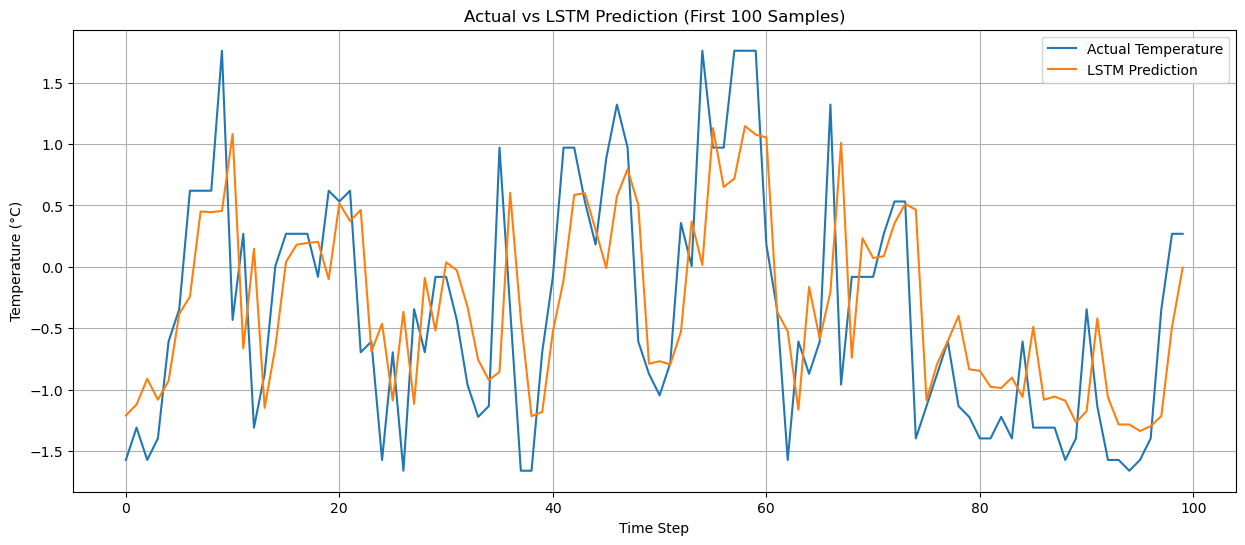

In [167]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,6))

plt.plot(y_test_temp[:100], label="Actual Temperature")
plt.plot(yp[:100], label="LSTM Prediction")

plt.title("Actual vs LSTM Prediction (First 100 Samples)")
plt.xlabel("Time Step")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.grid(True)

plt.show()